#**PLEASE SAVE A COPY OF THIS NOTEBOOK TO SUBMIT**


# Modeling: MultiModal AI — Homework 3
**MAS.S60 / 6.S985 • Spring 2026 • MIT**

In this homework, you will explore Vision-Language Models (VLMs) and gain hands-on experience fine-tuning one.

---

## Environment Setup

Go to the top menu:  
Runtime → Change runtime type → Hardware accelerator → Choose "A100"

If you do not have Colab Pro, you can sign up for a free student Colab Pro account here:  
https://colab.research.google.com/signup


# Part 1: Reading & Reflection (20 points)

### Required Reading
[Multimodal Few-Shot Learning with Frozen Language Models](https://arxiv.org/pdf/2106.13884)

[Quality Not Quantity: On the Interaction between Datase Design and Robustness of CLIP
](https://arxiv.org/pdf/2208.05516.pdf)

[Generative AI: Here to stay, but for good?](https://www.sciencedirect.com/science/article/pii/S0160791X2300177X)

---

### Questions
1. What types of multimodal data noise are typically present in multimodal datasets, and how can they negatively impact the performance of a model during training? Can you provide examples of multimodal data points that might be considered noisy? Furthermore, how might we develop estimators capable of distinguishing between noisy and noise-free multimodal data pairs? If you have unlimited fundings to use for data filtering and data cleaning, what would be the ideal way to clean the multimodal dataset?

The Schmidt et. al paper argues that the quality of the data is more important that the quality; combining models with two noisy datasets yield a combination of their performances instead of improving performance beyond individual performance, which may have been expected. For the CLIP/LAION discussion, the LAION filters web-crawled image-text pairs using CLIP similarity, but many of the text representations may not actually describe the image well. With Common Crawl as the dataset, it may be noisy as it has scraped information from the internet. Similarly, image captions from Wikipedia or Flickr/Reddit may have incomplete or inaccurate captions, or may even vary a lot in how different individuals describe the images.

2. What is the intuition of utilizing frozen large language models as the backbone for multimodal tasks? Which types of encoders would facilitate the integration of diverse information into a format understandable by LLMs? How do these LLMs process and interpret information from different modalities?

The intuition of utilizing frozen language models is that these models have a very good sense of world knowledge and many domains from learning the general representation/language of the words it has been trained on. Therefore, it should be able to adapt well to many different tasks and bind quickly to new words or concepts it learns ("fast binding"). It is not too challenging to encode the input, which may be a different modality, into an encoding the language model can understand, and have the language model parse or interpret the modality in the language domain. Having a frozen LM allows us to harness the useful structure and weights that the model has already learned and apply it to this new context. By only training the LM and fine-tuning the paired image-text data, we ensure that the model remains generalizable and won't overfit the multimodal context. Modality-specific encoders that map the input into the LLM's embedding space are equipped to facilitate integration into an LLM-understandable format. The encoder would take an image, for example, and convert it to a vector such that it is a sequence of embeddings with the same dimensionality as token embeddings. These models take multimodal data and process the information as if it were part of the input token sequence. It is able to attend to the embeddings in the token space, generate tokens autoregressively, and then those tokens are converted back into the image representation.


3. Ensuring the effectiveness of multimodal foundation models through high-quality instruction tuning is vital. A study detailed at [here](https://arxiv.org/pdf/2402.04333.pdf) introduces a strategy for selecting significant data specifically suited for enhancing instruction tuning for language models. A primary challenge in this approach is determining which data are most crucial for targeted instruction tuning. How can we accurately identify and select the most impactful data for enhancing instruction tuning in multimodal foundation models? Given the complexity of diverse and multimodal information, what strategies can ensure the effectiveness of instruction tuning data for specific tasks?

LESS seems to use gradient-based influence estimates to score candidate examples on how much they are expected to help the target task. To select the most impactful instruction-tuning data, we should first start with a task-defining seed set. We need a few validation examples that reflect the exact behavior that we want - image-based medical explanation, visual question answering, etc. The seed needs to reflect the capability of what we need, not just the topic of the data. Then, the authors score capability alignment, not just superficial similarity (like if the model mentions similar words or the outputs come from the same domain). In the multimodal setting, the estimator should still use gradient similarity. Having tags related to the multimodal task (like temporal reasoning for time-series data, or hallucination tendencies) helps to built LOSS standards across modality types.

4. With the advancement of generative AI, distinguishing between AI-generated and human-created content is becoming increasingly challenging. Besides watermarking, which has its limitations, are there other effective methods to differentiate between AI-generated and human-created content across various modalities (text, audio, video, image)? Or is it becoming virtually impossible to make this distinction?

It's definitely getting much harder to distinguish between AI-generated and human-created content. It seems like it's becoming increasingly harder for both humans and AI models to determine what has been generated by AI vs. a human. I believe that human vs. AI distinction will need to come from humans. We may need to create stricter guidelines on AI generation, maybe mandates where we have to specify where content is coming from, what type of device has created it, and whether a human prompted its creation.

5. For state-of-the-art video generation models like Sora, Yann Lecun mentioned in [here](https://twitter.com/ylecun/status/1758740106955952191) that Sora does not understand the real world and its corresponding physical rules. Do you agree with this view? Can the future development of generative AI systems truly incorporate real-world knowledge, or are they limited in this aspect? Is pursuing generative AI a viable path towards achieving Artificial General Intelligence (AGI)?

I believe that AI may be able to eventually better understand real world rules, but that it is still pretty far from that level of understanding. Similar to the platonic representation hypothesis, with great training, increased examples and experiences with the world, I think that various AI models will gradually develop deeper understanding of fundamental human-centered rules.

# Part 2: Testing and Fine-tuning VLMs (100 points)

# Problem 1: GPU Verification and Library Installation

Run the following code cell to verify that your environment is correctly configured.

This step ensures that **PyTorch** and **CUDA** can access the GPU.  
When the setup is correct, a **secret word** will appear in the output.

---

### In Your PDF Submission

Include:
- A **screenshot** or **code snippet** showing the printed GPU information.  
- The **secret word** displayed by your verification cell.

---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install transformers accelerate bitsandbytes pillow torch -q

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t = torch.randn(2, 3, device=device)
KEY = 42
cipher_bytes = [99, 10, 102, 101, 124, 111, 10, 103, 103, 107, 99]

if t.is_cuda:
    cipher = torch.tensor(cipher_bytes, dtype=torch.uint8, device=device)
    decoded = torch.bitwise_xor(cipher, KEY)
    torch.cuda.synchronize()
    secret = bytes(decoded.tolist()).decode("ascii")
    print("SECRET_WORD:", secret)
else:
    print("SECRET_WORD: (not on GPU)")

PyTorch version: 2.10.0+cpu
CUDA available: False
CUDA device count: 0
SECRET_WORD: (not on GPU)


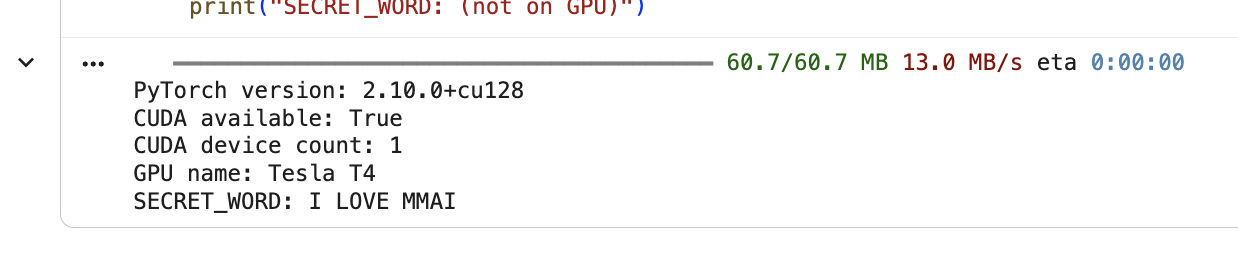

# Problem 2: Prepare Your Dataset (20 points)

## **PLEASE READ THIS ENTIRE SECTION BEFORE PROCEDING**

For Problem 2, you will **use the dataset you have collected from Homework 1 and Homework 2 or a completely new one if you prefer** to fine-tune a Vision-Language Model (VLM).

Even if your original data isn't image-based (e.g. it's audio, time-series, or text), you should find a way to **visualize it** meaningfully. The dataset you prepare will serve as the foundation for model fine-tuning in later steps.

---

### How to Convert Your Project Data Into Images

**If your project is not originally image-based, consider these ideas to generate visual input:**

| Data Type                    | Visual Representation Example                          |
|-----------------------------|---------------------------------------------------------|
| Time-series / sensor data   | Line plots or multi-panel charts (with axis labels)     |
| Audio / Music / Physiology  | Spectrograms or waveform plots                         |
| 3d data (point clouds, CAD) | Rendering/splicing into 2D images

You are encouraged to be **creative and domain-specific** in your visualizations.

**You will need to explore ways to convert your data into images if it does not already consist of this modality. Research on your own and come up with the needed code to do so. If you are still stuck on figuring this out, please reach out to a TA for help!**

### Download Example Training Data

The next block of code will download an example dataset and create a folder named `mmai-data/`.  
Inside this folder, you will find:

```
mmai-data/
├── images/
│   ├── 1.jpg
│   └── 2.jpg
└── data.jsonl
```

The file `data.jsonl` contains your training annotations.  
Each line represents one training example with the following fields:

```json
{
  "image": "images/1.jpg",
  "question": "List objects you see.",
  "answer": "cat, sofa, blanket, remote, cushion"
}
```

---

### Your Task

Now, prepare your own dataset following the same structure as the example.


Example structure:

```
mmai-data/
├── images/
│   ├── image_01.jpg
│   ├── image_02.jpg
│   ├── ...
└── data.jsonl
```

As part of this task. You should split the data into a train and test split. **The test split should consist of the images of data that you will not use in training.**


ANSWER: I generated train, validate, and test folders with images of my EEG dataset visualized. I had a line plot of the time-series data, in addition to spectrogram visualization of the same window. For each image, it's a 10-second window of the data.

In [3]:
import os, shutil, zipfile
from pathlib import Path

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Upload your dataset as a zip file to Google Drive, then
# replace the URL below with your own Google Drive share link.
#
# Your zip should unpack into a folder called mmai-data/ with:
#   mmai-data/
#   ├── images/
#   │   ├── image_01.jpg
#   │   ├── ...
#   │   └── image_16.jpg
#   └── data.jsonl
#
# Each line in data.jsonl should be a JSON object with three
# fields: "image", "question", and "answer". For example:
#
#   {"image": "images/1.jpg", "question": "List objects you see.", "answer": "cat, sofa, blanket, remote, cushion, tail, paw"}
#   {"image": "images/2.jpg", "question": "List objects you see.", "answer": "car, truck, road, bridge, exit sign, lamppost, building, sky"}
#
URL = "https://drive.google.com/file/d/14S_HZA4sbCCZnMsHS1o_jmK7rWEGwDiw/view?usp=sharing"
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

DATA_DIR = Path("/content/drive/MyDrive/MEng/6.S985/")
DATA_DIR.mkdir(parents=True, exist_ok=True)

!pip -q install gdown
import gdown

print("Downloading…")
downloaded_path = gdown.download(URL, output=None, quiet=False, fuzzy=True)
if not downloaded_path or not os.path.exists(downloaded_path):
    raise RuntimeError("Download failed. Check the URL or your Drive permissions.")

src = Path(downloaded_path)
dst = DATA_DIR / src.name
if src.resolve() != dst.resolve():
    shutil.move(str(src), str(dst))

print(f"\nFile saved to: {dst}")

if zipfile.is_zipfile(dst):
    extract_dir = DATA_DIR / dst.stem
    extract_dir.mkdir(exist_ok=True)
    print(f"Unzipping into: {extract_dir}")
    with zipfile.ZipFile(dst, "r") as zf:
        zf.extractall(extract_dir)
    print("Unzip complete.")

if dst.suffix.lower() == ".jsonl":
    print("\nSet this in your training cell:")
    print(f'DATA_JSONL = "{dst}"')

Downloading…


Downloading...
From: https://drive.google.com/uc?id=14S_HZA4sbCCZnMsHS1o_jmK7rWEGwDiw
To: /content/mmai-data.zip
100%|██████████| 346k/346k [00:00<00:00, 54.5MB/s]



File saved to: /content/drive/MyDrive/MEng/6.S985/mmai-data.zip
Unzipping into: /content/drive/MyDrive/MEng/6.S985/mmai-data
Unzip complete.


## Questions to Answer:

*   Explain some possible issues with converting non-image data into images (even if you did not have to do so, discuss what could be some issues).

One issue I had with converting non-image data into images was that I wasn't sure what the best scale was to represent the data on. Depending on the window, some data had high-amplitude data, and therefore a more compact scale better represented it. However, for most other data points, especially lower-amplitude data, it was better with a larger scale, so I had to find a good compromise between the two. I felt as though converting the data into am image left some of important information out, because all the numbers get converted into a visual data source. Additionally, the lne plot may show amplitude over tiem, but it might not be informative about the phase relationships between channels or specific frequency band activities that something like a spectrogram can highlight.

*   What are some possible issues with using visual representations of your data. Discuss some drawbacks of doing this (if you did not have to do the conversion as your data was already in the form of images, then discuss the drawbacks of converting those images to another modality like text, audio, etc.).

One issue is that, during training, a VLM or other model may struggle with invariance. Because I used the same formatting, colors, etc. for all my generated images of the data, the models may learn those representations instead of the underlying data patterns. In addition, because time series data often looks similar when plotted, very similar images may be generated for small temporal shifts or overlapping windows. This redundancy may lead to the model slowing down or unable to really learn distinct features.

* Discuss the strategy you decided on how to split your data into train/test splits. Why did you settle on this? Were any other alternative splits considered?

I decided to use a patient-wise split to avoid data leakage. This way, the model doesn't learn patient-specific patterns that may falsely increase test accuracy, but rather learns the true patterns of seizure waveforms. I settled on this because this is standard practice when using patient data.

Additionally, because seizures are very sparse in the grand scheme of each patient's EEG data, I used a stratified random splitting approach to ensure that the proportion of seizure vs non-seizure classes were consistent across splits.

I could've considered a time split, where earlier data is training data and the model is tested on data later in the EEG. However, this may not be ideal because the model may learn patient-specific patterns.

# Problem 3: Baseline Inference (10 points)

# Problem 3.1 Load the Model

Begin by running the following code to **load the base model** into memory. This step is required before training or making predictions.


In [ ]:
import io, requests, torch
from PIL import Image, UnidentifiedImageError
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

# 1) Load model + processor (processor handles BOTH text + vision)
processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)
print("Model and tokenizer loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

# Problem 3.2: Run the Model on Your 4 Held-Out Images

In this step, you will use the **pre-trained** `Qwen2.5-VL-3B-Instruct` model (no fine-tuning yet) to answer questions about the **held-out images** that were **not used in training**. You will then compare the model’s predictions with the ground-truth labels and reflect on its performance.

---

## Instructions

1. **Select four held-out images**  
   Choose four test images from your dataset that were excluded from training and prompt development.

2. **Ask a consistent question**  
   Use the same question for all images, or a small set of label-aligned questions.

3. **Run the model**  
   Use the provided code cell to run inference with the pre-trained model.  

4. **Record your results**  
   For each image, collect the model’s raw output and compare it to the ground-truth label(s). If there are too many images, then show a few examples.

---

## Reflection (5–8 sentences)

After running the model on your four images, briefly discuss:
- **What worked?**  
  Which prompts or parameter settings produced better results?
- **What failed?**  
  Were there recurring failure modes (e.g., hallucinations, vague answers)?
- **Patterns in mistakes**  
  Did errors correlate with certain categories, lighting conditions, or question phrasing?

---

## Suggested Output Format

| Image ID/URL | Question | Model Output | Ground Truth | Result |
|---------------|-----------|---------------|---------------|---------|
| `img_001.jpg` | “What objects are visible?” | cat, sofa | cat, sofa | Correct |
| `img_002.jpg` | “What objects are visible?” | road, truck, sign | road, car, sign | Incorrect |

Responses to the reflection:

Changing the system prompt to be more specific to this task ("you are an expert neurophysiologist") seemed to help it provide more detailed, technical explanations as to why it classified the segment as a seizure or non-seizure segment. It did seem to hallucinate a good amount in terms of classifying seizure. For example, I provided two seizure classified and two non-seizure classified examples, and it "suggested" that all four were indicative of seizure-patterns. While the explanations seemed to be based in some basic physiology principles like the time-variance of frequencies and spike-like patterns, I'm not sure it really fully understood the full time-dependency of frequency changes like a real neurophysiologist. However, it was still able to "see" and "read" the EEG which was quite interesting. Since all the images were generated from the raw EEG data in the same manner, I was unable to test the model on lighting conditions or test if it was invariant to image quality/characteristics. However, phrasing the question was interesting - I tried to push it to make a more definitive answer and that's when it seemed to hallucinate and indicate 'seizure' more often than not.

In [ ]:
import io
import os
import requests
import torch
from typing import Optional, Dict, Any, List
from PIL import Image, UnidentifiedImageError
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from IPython.display import display # Import display for showing images in Colab

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Provide a list of local paths to your held-out test images.
# Example: ["/content/drive/MyDrive/path/to/image1.jpg", "/content/drive/MyDrive/path/to/image2.jpg"]
TEST_IMAGE_PATHS: List[str] = [
    "/content/drive/MyDrive/MEng/6.S985/mmai-data/test/images/sub-014_run-02_window-00033.png", # non-sz example
    "/content/drive/MyDrive/MEng/6.S985/mmai-data/test/images/sub-014_run-02_window-00103.png", # non-sz example
    "/content/drive/MyDrive/MEng/6.S985/mmai-data/test/images/sub-031_run-03_window-11302.png", # seizure example
    "/content/drive/MyDrive/MEng/6.S985/mmai-data/test/images/sub-034_run-04_window-00427.png"  # seizure example
]
QUESTION: str = "Classify this as a seizure event or non-seizure brain activity. Explain why using EEG physiological principles briefly." # Use a consistent question
SYSTEM_PROMPT: str = "You are an expert neurophysiologist who understand the complexities behind EEG, especially in the context of seizure detection. These patients are wearing a bte-EEG, which has two channels only. Seizure and non-seizure events have been annotated by real trained physicians, but we aren't showing you those ground-truth labels."
# SYSTEM_PROMPT: str = "You are a helpful assistant."
MAX_NEW_TOKENS: int = 128
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
DO_SAMPLE: bool = False           # set True for non-greedy decoding
TEMPERATURE: float = 0.7          # used only if DO_SAMPLE=True
TOP_P: float = 0.9                # used only if DO_SAMPLE=True
MODEL_ID: str = "Qwen/Qwen2.5-VL-3B-Instruct"
FORCE_CPU: bool = False           # force CPU even if CUDA is available
DTYPE_IF_GPU = torch.bfloat16     # prefer bfloat16 on recent GPUs/Colab
DTYPE_IF_CPU = torch.float32

def get_device_and_dtype() -> tuple[torch.device, torch.dtype, Optional[Dict[str, Any]]]:
    """Choose device/dtype and (optionally) a device_map for accelerate-style placement."""
    use_cuda = torch.cuda.is_available() and not FORCE_CPU
    device = torch.device("cuda") if use_cuda else torch.device("cpu")
    torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
    device_map = "auto" if use_cuda else None
    return device, torch_dtype, device_map


def load_image(path_or_url: str) -> Image.Image:
    """Fetch image from URL or load from local path, return a RGB PIL.Image with robust fallback."""
    if path_or_url.startswith(("http://", "https://")):
        resp = requests.get(path_or_url, timeout=30)
        resp.raise_for_status()
        try:
            return Image.open(io.BytesIO(resp.content)).convert("RGB")
        except UnidentifiedImageError:
            # Fallback: write to disk then reopen (sometimes fixes truncated headers)
            tmp_path = "temp_image.jpg"
            with open(tmp_path, "wb") as f:
                f.write(resp.content)
            img = Image.open(tmp_path).convert("RGB")
            try:
                os.remove(tmp_path)
            except Exception:
                pass
            return img
    else:
        # Assume local file path
        return Image.open(path_or_url).convert("RGB")


def build_chat_messages(image: Image.Image, question: str) -> list[dict]:
    """Create a single-turn, image+text chat for Qwen-VL processors."""
    return [
        {
            "role": "system",
            "content": [
                {"type": "text", "text": SYSTEM_PROMPT}
            ],
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question},
            ],
        }
    ]


def main() -> None:
    device, torch_dtype, device_map = get_device_and_dtype()

    # 1) Load model + processor
    processor = AutoProcessor.from_pretrained(MODEL_ID)
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        MODEL_ID,
        torch_dtype=torch_dtype,
        device_map=device_map,
    )
    print("Model and processor loaded successfully.")

    for i, image_path in enumerate(TEST_IMAGE_PATHS):
        print(f"\n--- Processing Image {i+1}: {image_path} ---")

        # 2) Load image
        try:
            image = load_image(image_path)
            print("Image:")
            display(image) # Display the image in Colab
        except FileNotFoundError:
            print(f"Error: Image not found at {image_path}. Skipping this image.")
            continue
        except Exception as e:
            print(f"Error loading image {image_path}: {e}. Skipping this image.")
            continue

        # 3) Build chat
        messages = build_chat_messages(image, QUESTION)

        # 4) Apply chat template and preprocess
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[image], return_tensors="pt")

        # 5) Move to the right device
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        # 6) Generate
        gen_kwargs = dict(max_new_tokens=MAX_NEW_TOKENS)
        if DO_SAMPLE:
            gen_kwargs.update(dict(do_sample=True, temperature=TEMPERATURE, top_p=TOP_P))

        with torch.no_grad():
            gen_ids = model.generate(**inputs, **gen_kwargs)

        # 7) Decode
        out = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
        print("\n=== MODEL OUTPUT ===")
        print(out)
        print("\n" + "="*50) # Separator for clarity


if __name__ == "__main__":
    main()


In [ ]:
import json
file_path = '/content/drive/MyDrive/MEng/6.S985/mmai-data/test/data.jsonl'
data = []
with open(file_path, 'r') as file:
  for line in file:
    data.append(json.loads(line))

# Find and print the first example where 'answer' is 'seizure'
seizure_example = None
count=0
for item in data:
    if item.get('answer') == 'seizure':
        seizure_example = item
        count+=1

if seizure_example:
    print(seizure_example)
    print(count)
else:
    print("No example found with 'answer' = 'seizure' in the test dataset.")

# in test dataset: 'test/images/sub-034_run-04_window-00427.png' is 'seizure'
# also 'test/images/sub-031_run-03_window-11302.png' is seizure'

Output from problem 3
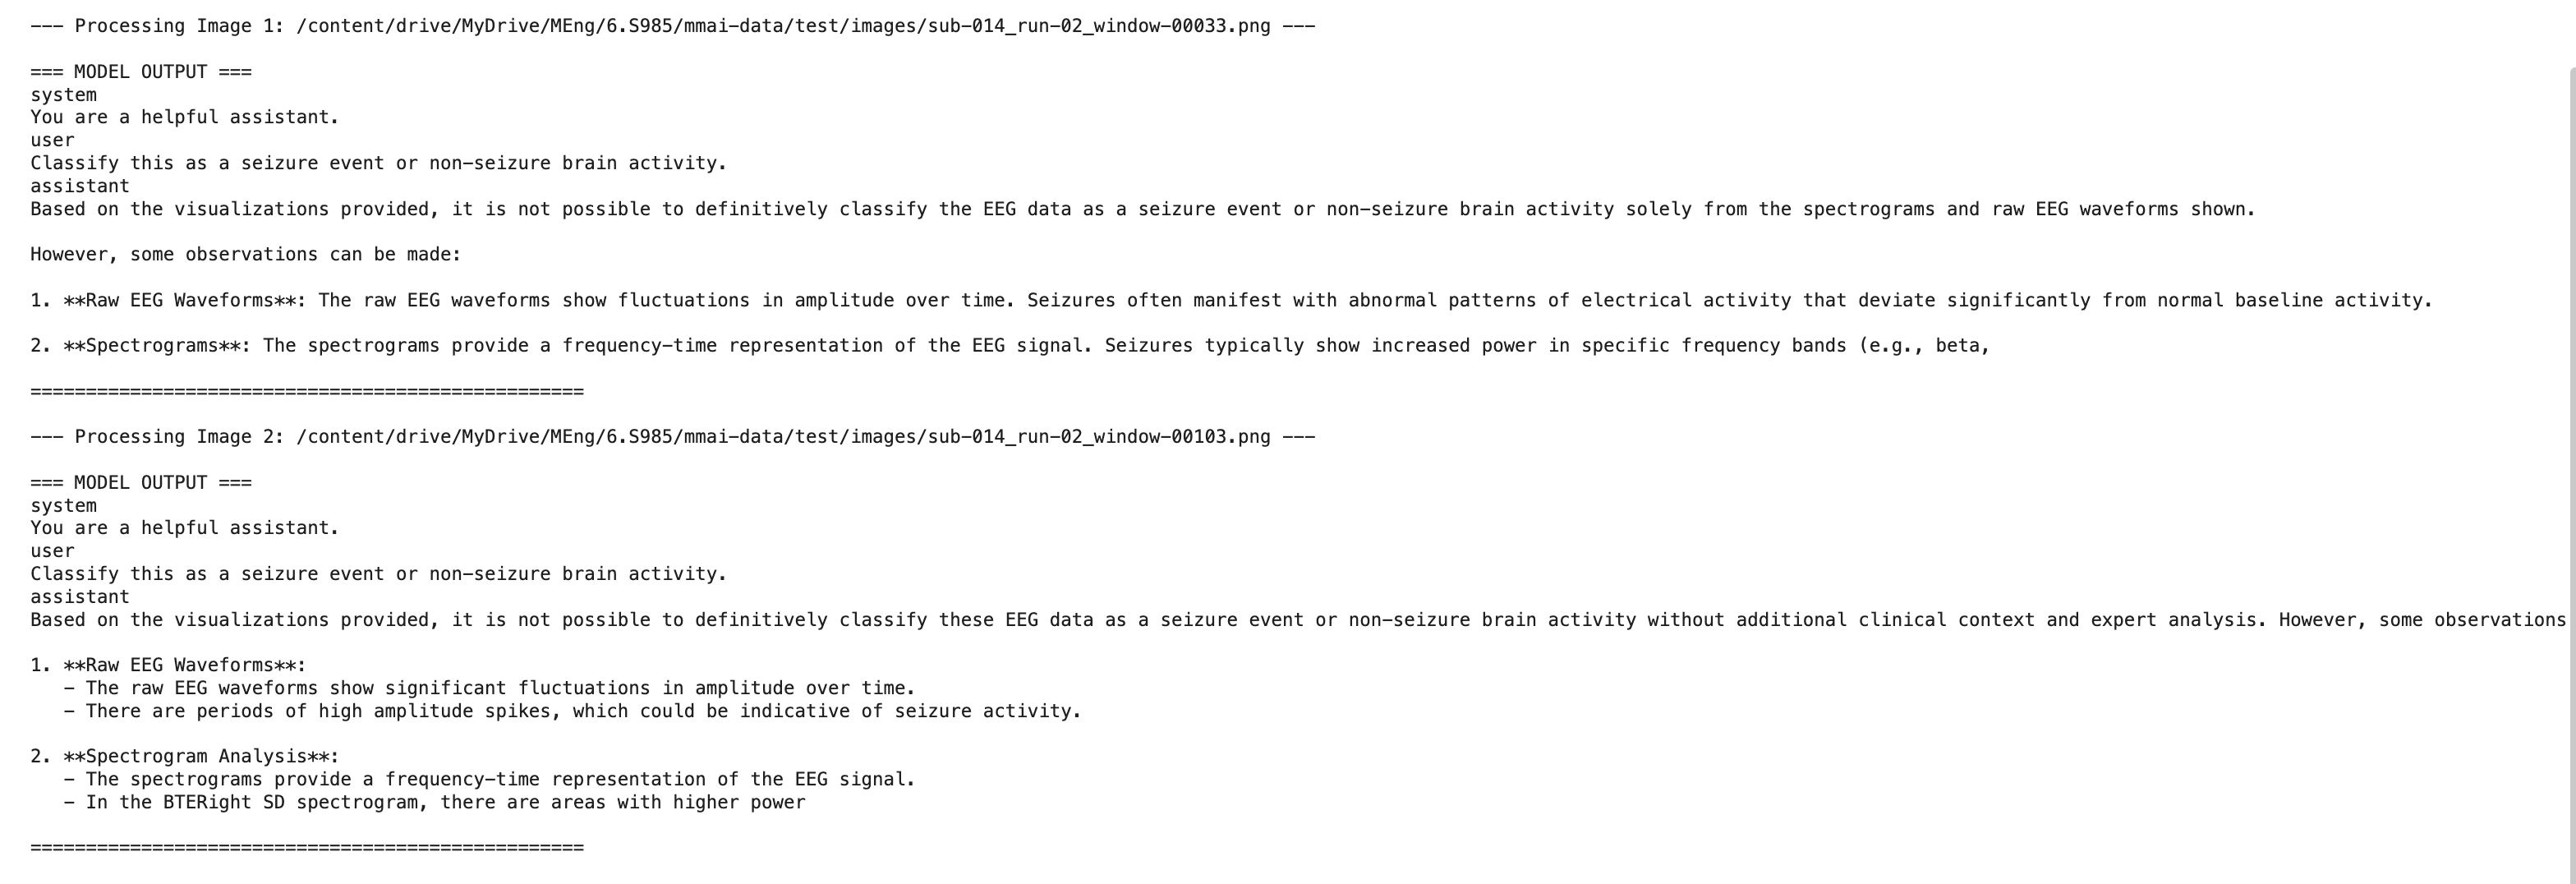

Output from problem 3

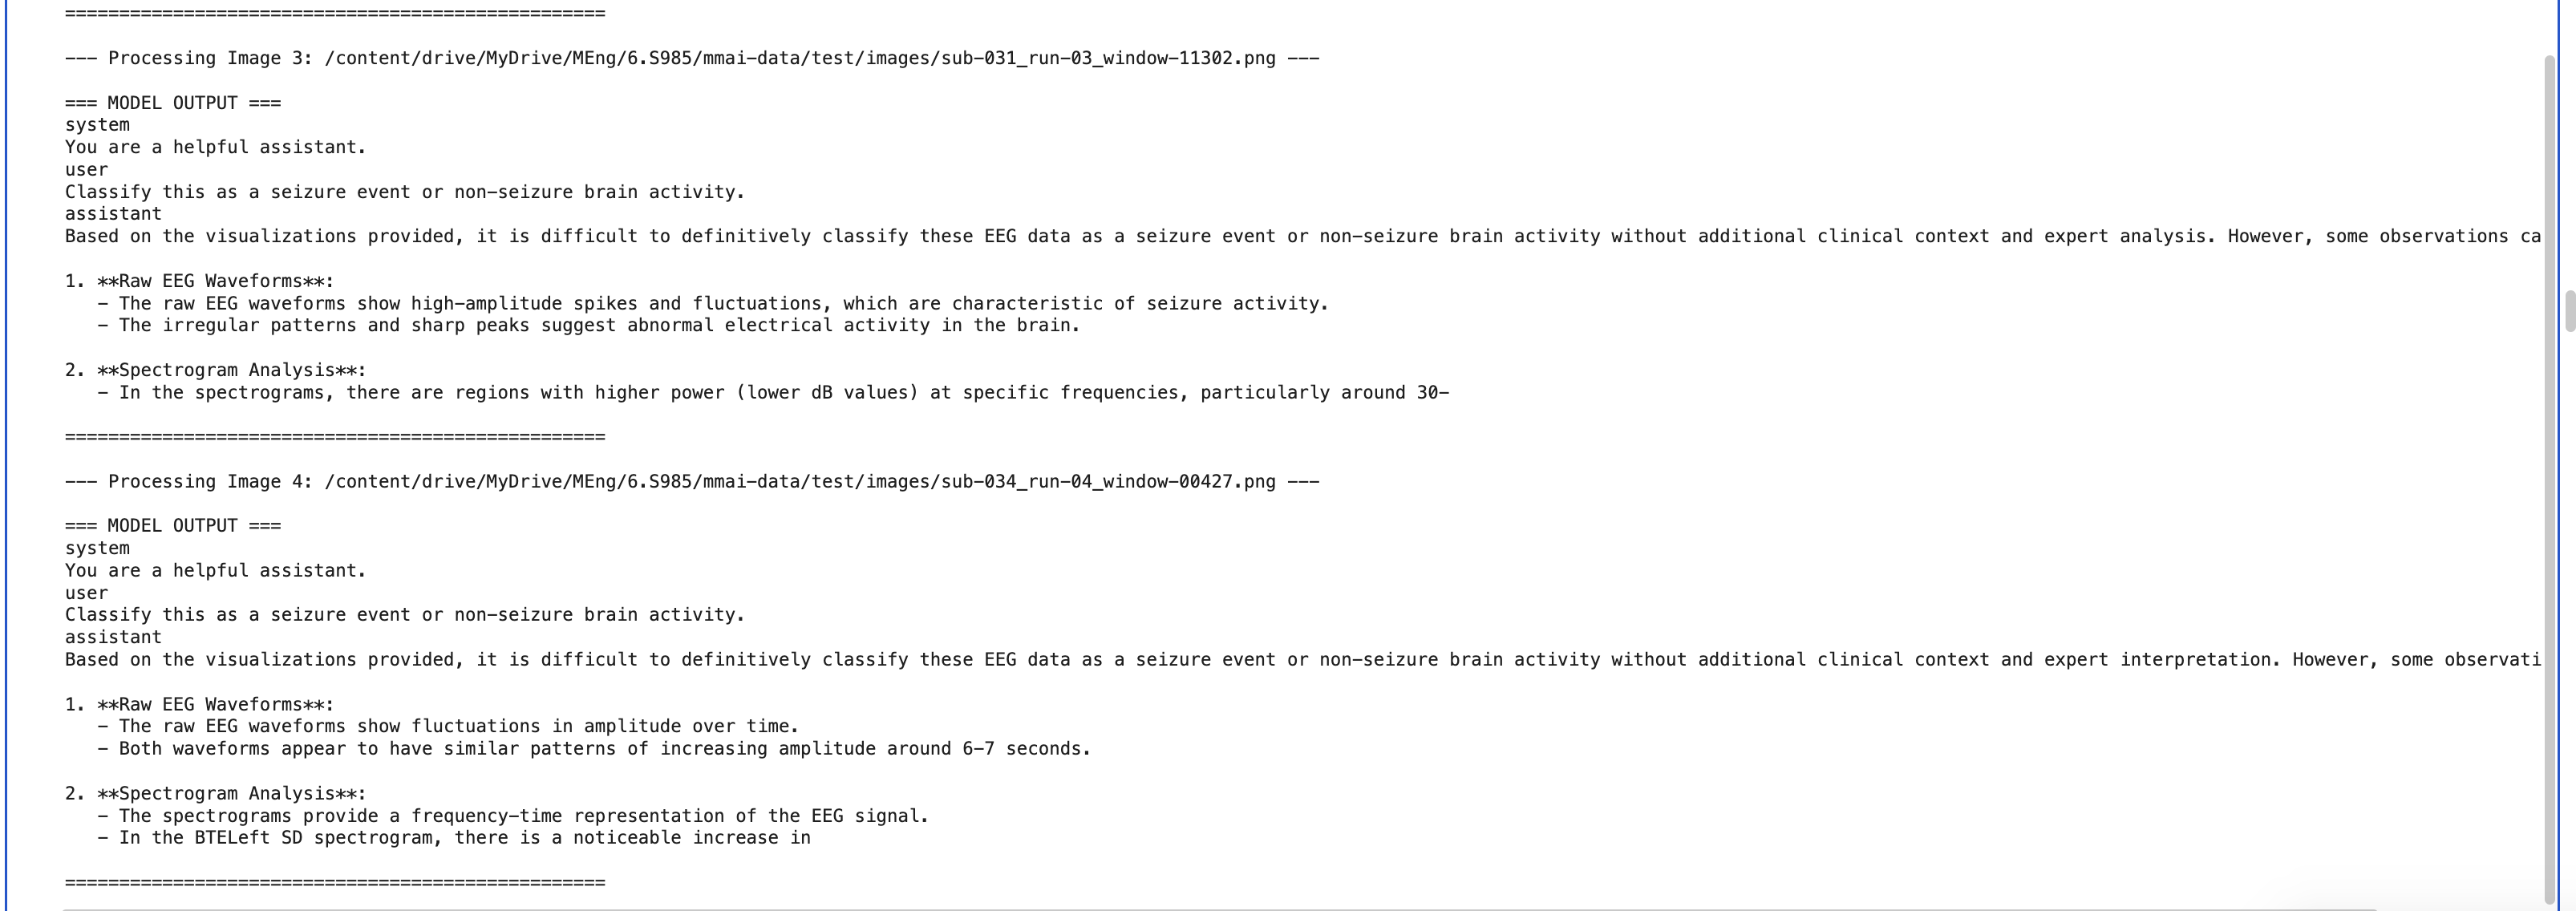

# Problem 4: Prompt Engineering (15 points)

In this step, you'll experiment with **prompt design** to explore how different instructions influence model performance.

---

### Instructions

1. Modify the **`SYSTEM_PROMPT`** variable inside the **CHANGE ME** section of the code above.  
2. Re-run the corresponding code cell to observe how the model's responses change.  
3. Test various prompt strategies, such as:
   - Adding **examples** (few-shot prompting)
   - Restricting **answer formats** (e.g., "Answer with one word")
   - Asking for **explanations** or **step-by-step reasoning**
4. Compare your new results with the baseline output.

---

### Reflection

In your write-up, discuss:
- Which types of prompt changes improved performance?  

    Changing the SYSTEM_PROMPT to tell the model that it was an expert clinical neurophysiologist made the output a bit more technical, and the model gave explanations based on the fact that high-frequency activity is often associated with epileptic seizures. Additionally, when I ask it to provide explanation, it cites power and frequency changes asosciated with seizure. It still advised that a real physician oversee the EEG, which I think is a great safeguard against over-reliance on AI for healthcare diagnoses. However, once we change the system prompt to tell it that it's an MD and neurophysiology expert, that precaution disappears.

    When I ask it to respond in only one word and classify the window as seizure or non-seizure, it classifies all four as seizure (only the last 2 are seizure). It seems to push itself to a more dramatic conclusion when pressured.
- Did adding context or structure help the model reason more effectively?

    Adding context about this dataset (that it's a wearable bte-EEG dataset) does not change the model's output too much. Explaining the motivation behind seizure diagnosis and prompting a more technical answer makes the model give a more scientific answer for its classification.
- Were there any surprising or inconsistent results?

    The model seemed to be pretty inconsistent in classifying seizure/nonseizure. Based on my prompt, at the beginning it tended to predict non-seizure with acknowledged uncertainty, while later prompts all predicted seizure (still with uncertainty). I found this interesting because it seemed like contextualizing the model and telling it that is was a neurophysiologist seemed to spur it to indicate seizure presence more, which seems to create more false positives.


# Problem 5: LoRA Fine-Tuning (20 points)

In this step, you'll fine-tune a **Vision-Language Model (VLM)** using **LoRA (Low-Rank Adaptation)** on your dataset.  
This exercise will help you understand how different hyperparameters influence performance, GPU memory usage, and output quality.

### Instructions

Run the code block below.  
If you followed the **`mmai-data`** example, the script should automatically detect and load your training dataset.

### Adjust and experiment with

- **Number of epochs** (`NUM_EPOCHS`)
- **Learning rate** (`LR`)
- **Batch size per device** (`BSZ_PER_DEV`)
- **Gradient accumulation steps** (`GRAD_ACCUM`)
- **Evaluation split ratio** (`EVAL_SPLIT`)
- **Random seed** (`SEED`)
- **Sequence length** (`MAX_SEQ_LEN`)
- **Image resolution** (`SHORTEST_EDGE`)
- **LoRA rank** (`LORA_R`)
- **LoRA alpha** (`LORA_ALPHA`)
- **LoRA dropout** (`LORA_DROPOUT`)
- **LoRA target modules** (`LORA_TARGET`)

---

```python
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

# (Modify the parameters below in the Colab cell)

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================
```

### Q&A

**Q:** What should I do if I encounter an out-of-memory issue?  
**A:** Your image might be too large. Try resizing it by adding the following line back into your code and experiment with different pixel values:

```python
img.thumbnail((128, 128))  # NOTE: If you run into an out-of-memory error, try adding this line back.
```


In [ ]:
# ==== Qwen2.5-VL-3B-Instruct • FP16 LoRA ====

from IPython.display import display, HTML
import os, io, json, requests, torch, random, hashlib
from dataclasses import dataclass
from typing import Any, Dict, List
from PIL import Image
from torch.utils.data import Dataset
import torch.nn as nn
from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model

# Environment hygiene
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:64"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 1
LR: float        = 1e-4
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 1
# EVAL_SPLIT: float = 0.1 # No longer needed as we are loading pre-split data
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM

# Paths to your pre-split data.jsonl files
TRAIN_DATA_JSONL: str  = "/content/drive/MyDrive/MEng/6.S985/mmai-data/train/data.jsonl"
VAL_DATA_JSONL: str    = "/content/drive/MyDrive/MEng/6.S985/mmai-data/val/data.jsonl"

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
# Paths
# DATA_JSONL: str  = "/content/drive/MyDrive/MEng/6.S985/mmai-data/train/data.jsonl" # No longer directly used
OUTPUT_DIR: str  = "/content/qwen2_5_vl_lora_fp16_t4"

MODEL_ID: str     = "Qwen/Qwen2.5-VL-3B-Instruct"
CACHE_DIR: str    = "/content/cache_images"
IMAGE_TIMEOUT: int = 15

# LoRA configuration (attention-only keeps memory low)
LORA_R: int          = 4
LORA_ALPHA: int      = 8
LORA_DROPOUT: float  = 0.05
LORA_TARGET: list[str] = ["q_proj", "k_proj", "v_proj", "o_proj"]

# Device / dtype policy
FORCE_CPU: bool   = False
DTYPE_IF_GPU      = torch.float16
DTYPE_IF_CPU      = torch.float32


# Repro and cache dirs
torch.manual_seed(SEED); random.seed(SEED)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# --------------------
# Demo data (create if missing)
# --------------------
def _ensure_user_data_paths(train_path: str, val_path: str):
    if os.path.exists(train_path) and os.path.exists(val_path):
      display(HTML(
          "<div style='color:white; background-color:#2e7d32; padding:10px; border-radius:6px;'>"
          "<strong>Using custom training and validation data:</strong> "
          f"Loaded datasets from <code>{train_path}</code> and <code>{val_path}</code>. "
          "</div>"
      ))
      return True

    display(HTML(
        "<div style='color:white; background-color:#b71c1c; padding:10px; border-radius:6px;'>"
        "<strong>Warning:</strong> Training or Validation dataset not found at specified paths. "
        "Please ensure your JSONL files exist at the provided TRAIN_DATA_JSONL and VAL_DATA_JSONL paths."
        "</div>"
    ))
    return False

_ensure_user_data_paths(TRAIN_DATA_JSONL, VAL_DATA_JSONL)


# --------------------
# Minimal JSONL dataset
# --------------------
class JsonlVisionLangDataset(Dataset):
    def __init__(self, jsonl_path: str):
        self.samples: list[dict] = []
        with open(jsonl_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line: continue
                ex = json.loads(line)
                if {"image","question","answer"} - set(ex.keys()): continue
                self.samples.append(ex)
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx: int) -> Dict[str, Any]: return self.samples[idx]

# Load pre-split datasets
train_ds_raw = JsonlVisionLangDataset(TRAIN_DATA_JSONL)
val_ds_raw   = JsonlVisionLangDataset(VAL_DATA_JSONL)

# No manual splitting needed here, directly assign to train_data and val_data
train_data = [sample for sample in train_ds_raw]
val_data   = [sample for sample in val_ds_raw]

class ListDataset(Dataset):
    def __init__(self, data_list):
        self.data_list = data_list
    def __len__(self):
        return len(self.data_list)
    def __getitem__(self, i):
        return self.data_list[i]


# --------------------
# Cache images locally (avoid network hiccups)
# --------------------
# Define the base directory for your mmai-data folder
MMAI_DATA_BASE_DIR = "/content/drive/MyDrive/MEng/6.S985/mmai-data"

def cache_image(url_or_path: str, base_dir: str) -> str:
    # Remote URL: download and cache
    if url_or_path.startswith(("http://", "https://")):
        h = hashlib.md5(url_or_path.encode()).hexdigest()
        local = os.path.join(CACHE_DIR, f"{h}.jpg")
        if not os.path.exists(local):
            r = requests.get(url_or_path, timeout=IMAGE_TIMEOUT); r.raise_for_status()
            with open(local, "wb") as f: f.write(r.content)
        return local

    # Local path: make absolute relative to the provided base_dir
    candidate = url_or_path
    if not os.path.isabs(candidate):
        candidate = os.path.join(base_dir, url_or_path)

    if not os.path.exists(candidate):
        raise FileNotFoundError(
            f"Image not found: {candidate} (from '{url_or_path}'). "
            f"Expected under {base_dir}/"
        )
    return candidate


# print(train_data[0]['image'])
for ex in train_data: ex["image"] = cache_image(ex["image"], MMAI_DATA_BASE_DIR)
for ex in val_data:   ex["image"] = cache_image(ex["image"], MMAI_DATA_BASE_DIR)

train_ds = ListDataset(train_data)
val_ds   = ListDataset(val_data)


# --------------------
# Image loader
# --------------------
def load_image(img_path: str) -> Image.Image:
    img = Image.open(img_path).convert("RGB")
    # img.thumbnail((128, 128))  # NOTE: if you run into out of memory error, try adding this line back
    return img


# --------------------
# Processor + Model (FP16 on GPU, FP32 on CPU)
# --------------------
use_cuda = torch.cuda.is_available() and not FORCE_CPU
torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
device_map = "auto" if use_cuda else None

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()


# --------------------
# Collator (truncate to keep sequences small)
# --------------------
@dataclass
class VLDataCollator:
    processor: Any
    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        images, texts = [], []
        for ex in features:
            img = load_image(ex["image"])
            messages = [
                {"role": "user", "content": [
                    {"type":"image","image": img},
                    {"type":"text","text": ex["question"]},
                ]},
                {"role": "assistant", "content": [
                    {"type":"text","text": ex["answer"]},
                ]},
            ]
            text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
            images.append(img); texts.append(text)

        batch = self.processor( # type: ignore
            text=texts,
            images=images,
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LEN,
            return_tensors="pt",
        )
        labels = batch["input_ids"].clone()
        labels[batch["attention_mask"] == 0] = -100
        batch["labels"] = labels

        for im in images:
            try: im.close()
            except: pass

        return batch

collator = VLDataCollator(processor)


# --------------------
# FP16 loss trainer to avoid fp32 upcast OOM
# --------------------
class FP16CLMTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,
        **kwargs,
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Shift for causal LM
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()

        loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss


# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,

    eval_strategy="no",
    save_strategy="steps",
    save_steps=10_000,

    fp16=use_cuda, bf16=False,
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)


# **Questions to answer:**

1. Report the settings you used to get the best model.

The runtime crashed and I was out of compute units by the time of submission (despite starting this on Thursday). However, the best model I was able to get had these settings:

NUM_EPOCHS: int  = 1
LR: float        = 1e-3
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 1
SEED: int        = 42
MAX_SEQ_LEN: int = 384  # try 384 if VRAM is tight
SHORTEST_EDGE: int = 144  # smaller saves VRAM
  
2. Which hyperparameters did you find have the most impact in the model’s performance?

I found that the learning rate had the biggest impact in the model's performance.

3. Why do you think that is?

The learning rate is often considered one of the most critical hyperparameters, and its impact can be profound for several reasons. First, it dictates the step size taken during each iteration of the optimization process. It determines how much the model's internal weights are adjusted in response to the calculated gradients (which indicate the direction to minimize loss).

Second, the LR controls convergence speed and stability. Too high a learning rate can cause the model to overshoot the optimal solution repeatedly, leading to unstable training and sometimes divergence. It can prevent the model from converging to a good solution. On the other hand, too low a learning rate makes the model update its weights very slowly. The training times become a lot larger and can cause the model to get stuck in a suboptimal local minimum, failing to reach the best possible performance. An optimal learning rate allows the model to converge efficiently and stably towards a good minimum in the loss function.

Lastly, when fine-tuning a pre-trained model like Qwen2.5-VL with LoRA, it already possesses a lot of learned knowledge and strong feature representations. Too high a learning rate may corrupt the pre-trained representations, almost "unlearning" what the model already knew. Since LoRA specifically fine-tunes a small subset of parameters (the adapter layers), these adapters are designed to make subtle, effective changes. An inappropriate learning rate can cause even these small changes to change the output of the larger base model, causing poor performance.

In summary, the learning rate controls how effective and efficient the model is at learning and adapting to the new data, which is important when fine-tuning a complex VLM.

# Problem 6: Post-Training Evaluation (30 points)

# Problem 6.1 Load the Trained LoRA Adapter

Once your fine-tuning is complete, load the trained **LoRA adapters** back onto the original model to perform inference, that is, to generate predictions or analyze new images.

Simply run the code in the next code block.  
It will automatically attach your fine-tuned LoRA weights and prepare the model for evaluation.


In [ ]:

# --------------------
# Inference with adapters
# --------------------
from peft import PeftModel
base = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    # device_map="cuda:0",
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)
ft_model = PeftModel.from_pretrained(base, OUTPUT_DIR)
ft_model.eval()
print("LoRA adapters loaded. Ready for inference.")

# Problem 6.2 Re-Test on Held-Out Images

Re-test the same **held-out images** used in your baseline evaluation.

Compare the **pre-trained** (in Step 2.2) and **fine-tuned** model outputs:

- Which questions showed improvement?  
- Did LoRA fine-tuning correct any earlier mistakes?  
- Were any new errors or biases introduced after fine-tuning?

Document your observations and include examples where possible.


NOTE: I ran out of compute units (with a student plan) and had to restart my Colab, so I am unable to provide the images here that were produced from the trained LoRA model. I have spent the past 5 days working on the coding part of this homework (aka I did not procrastinate) so I'd appreciate some grace on this, since Colab has been giving me issues with obtaining compute. I will try to run on a GPU as soon as I am allowed more compute and re-submit if possible. See image below for proof - thank you.

Q1

The questions where we prompted the model to explain its basis for classifying seizure vs. non-seizure improved, as did the "give a one word answer - classify this EEG segment as seizure or non-seizure" improved as well. Previously, the model was a little inconsistent, sometimes assigning all the examples to seizure, sometimes assigning none of them to seizure.

Q2

However, after the LoRA fine-tuning, it seemed to be more discriminative and classify a mix of seizure and non-seizure examples, and would explain each in a good amount of detail.

Q3

The model didn't seem to include any new biases, but it still heavily emphasized that it was "not a trained doctor" and still recommended that a real physician oversee the classification of seizure vs. non-seizure. In this sense it seemed to double-down or encourage real medical evaluation, which was promising.

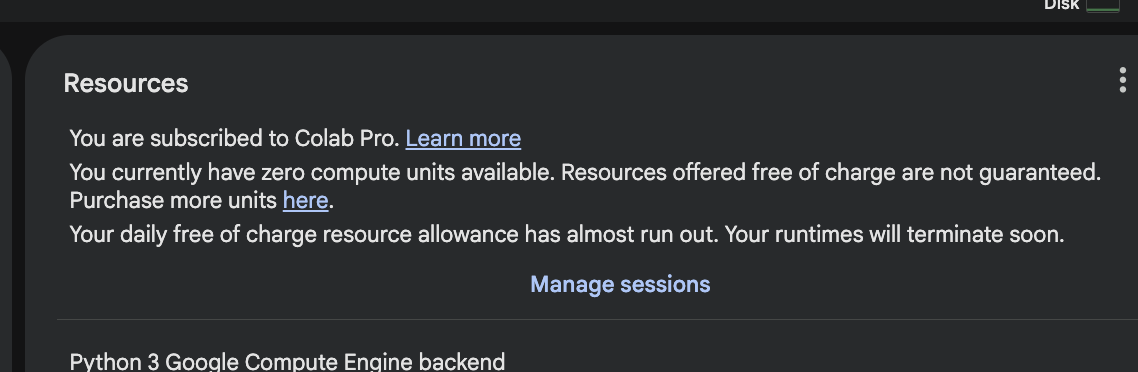

In [ ]:
from IPython.display import display
import PIL.Image

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
TEST_IMAGE_PATHS: List[str] = [
    "/content/drive/MyDrive/MEng/6.S985/mmai-data/test/images/sub-014_run-02_window-00033.png", # non-sz example
    "/content/drive/MyDrive/MEng/6.S985/mmai-data/test/images/sub-014_run-02_window-00103.png", # non-sz example
    "/content/drive/MyDrive/MEng/6.S985/mmai-data/test/images/sub-031_run-03_window-11302.png", # seizure example
    "/content/drive/MyDrive/MEng/6.S985/mmai-data/test/images/sub-034_run-04_window-00427.png"  # seizure example
]
TEST_QUESTION: str = "Classify this EEG window as seizure or non-seizure."
MAX_NEW_TOKENS: int = 128
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

# Load image
for TEST_IMAGE in TEST_IMAGE_PATHS:
  loaded_img = Image.open(TEST_IMAGE).convert("RGB")

  # Display image
  print("Image:")
  display(loaded_img)

  # Prepare messages
  messages = [{"role": "user", "content": [
      {"type": "image", "image": loaded_img},
      {"type": "text", "text": TEST_QUESTION}
  ]}]

  # Encode and generate
  text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
  inputs = processor(text=[text], images=[loaded_img], return_tensors="pt").to(ft_model.device)

  with torch.no_grad():
      out_ids = ft_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)

  # Decode output
  output_text = processor.batch_decode(out_ids, skip_special_tokens=True)[0]
  print("Model Output:", output_text)


# Problem 7: Final Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. What concept did you find the most interesting?

    I found it very interesting how, even before training with the LoRA adaptors, just prompting the model differently (changing from "You are a helpful assistant" to something more domain-specific like "You are an expert neurophysiologist who reads EEG time-series data" changed the output signficantly. The model started to give more educated-sounding outputs and was a little more confident with its answer, despite not changing anything about the model (just prompting it in a different way). This was eye-opening for me to see how influential prompt engineering can be.

2. Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.

  I think the concept of using a pre-trained language model might be really helpful for my goal (and project!). It seems that the model was able to pull useful information about spike and other seizure patterns and how they commonly appear in EEG signals, and was able to explain what it "saw" using those terms. This would also help with interpretability, if the model is able to explain what and how it comes to the decision of seizure vs. non-seizure.

3. Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more?

  It would've been interesting to see the ideas of fusion vs. fission covered in the homework. Those concepts still feel a bit abstract to me (especially fission), so I would've enjoyed learning about how that is done in practice with two or more modes of data.